In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

p = Path.cwd()
while p != p.parent and not (p / "src").exists():
    p = p.parent

proj_root = p
print("Using project root:", proj_root)
sys.path.insert(0, str(proj_root))
STORE_PATH = Path(proj_root/"data/experience_store.json")
TIMELINE_PATH = Path(proj_root/"data/timeline.csv")
REQUIRED_LEVELS_PATH = Path(proj_root/"config/activity_requirements.yaml")

Using project root: /Users/martinschmauch/Code/TUMCode/MasterThesis


# Experience Store Analysis

In [32]:
# json is in format {row_name: {col_name1: value1, col_name2: value2, ...}, ...}
# read json into pandas dataframe
store_df = pd.read_json(STORE_PATH, orient='index')
# read yaml into dict
import yaml
with open(REQUIRED_LEVELS_PATH, 'r') as f:
    required_levels = yaml.safe_load(f)
required_levels = required_levels["activity_requirements"]

In [3]:
# show top 10 resources for W_Assess potential fraud by experience leve
top_resources = store_df[store_df["activity_name"] == "W_Assess potential fraud"]
top_resources.sort_values("experience_level", ascending=False)[["resource_id", "mean_duration", "count", "experience_level"]].head(10)

,resource_id,mean_duration,count,experience_level
"('User_144', 'W_Assess potential fraud', 'case:ApplicationType=NONE|case:LoanGoal=NONE')",User_144,2123,32,68.438083
"('User_36', 'W_Assess potential fraud', 'case:ApplicationType=NONE|case:LoanGoal=NONE')",User_36,3600,5,5.554779
"('User_38', 'W_Assess potential fraud', 'case:ApplicationType=NONE|case:LoanGoal=NONE')",User_38,7200,0,0.000000
"('User_109', 'W_Assess potential fraud', 'case:ApplicationType=NONE|case:LoanGoal=NONE')",User_109,7200,0,0.000000
"('User_83', 'W_Assess potential fraud', 'case:ApplicationType=NONE|case:LoanGoal=NONE')",User_83,7200,0,0.000000
"('User_2', 'W_Assess potential fraud', 'case:ApplicationType=NONE|case:LoanGoal=NONE')",User_2,7200,0,0.000000
"('User_93', 'W_Assess potential fraud', 'case:ApplicationType=NONE|case:LoanGoal=NONE')",User_93,7200,0,0.000000
"('User_39', 'W_Assess potential fraud', 'case:ApplicationType=NONE|case:LoanGoal=NONE')",User_39,7200,0,0.000000
"('User_123', 'W_Assess potential fraud', 'case:ApplicationType=NONE|case:LoanGoal=NONE')",User_123,7200,0,0.000000
"('User_41', 'W_Assess potential fraud', 'case:ApplicationType=NONE|case:LoanGoal=NONE')",User_41,7200,0,0.000000


Activity 'W_Personal Loan collection' has required experience level: 21.0
Activity 'W_Shortened completion' has required experience level: 21.0
Activity 'W_Handle leads' has required experience level: 22.0
Activity 'W_Call after offers' has required experience level: 30.0
Activity 'W_Complete application' has required experience level: 32.0
Activity 'W_Assess potential fraud' has required experience level: 35.0
Activity 'W_Validate application' has required experience level: 36.0
Activity 'W_Call incomplete files' has required experience level: 40.0


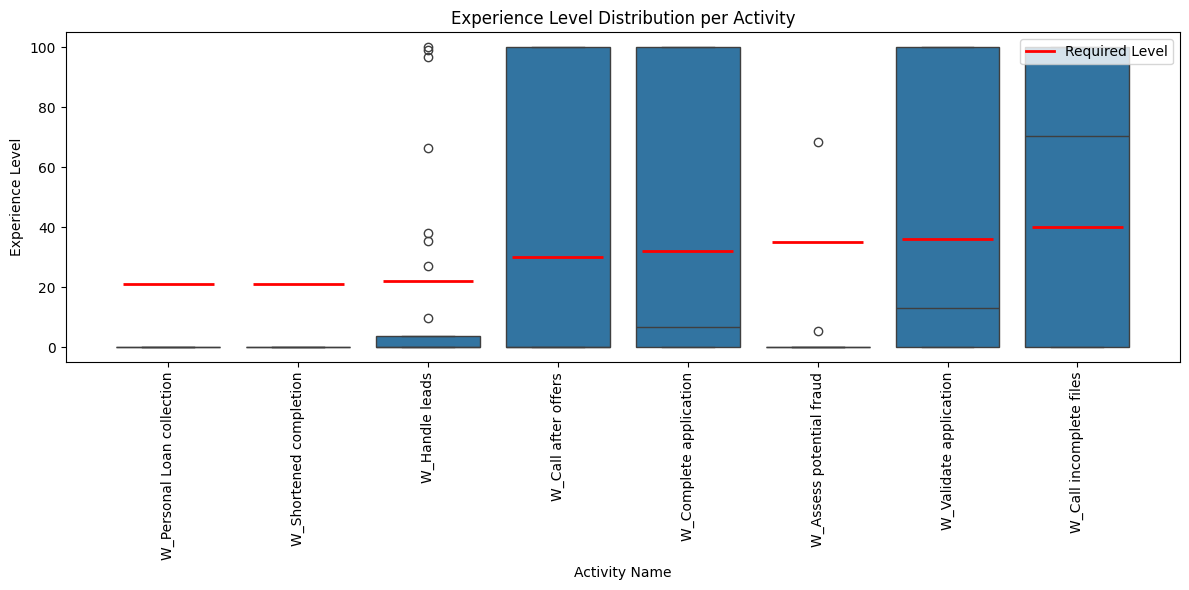

In [35]:
plt.figure(figsize=(12, 6))
activity_order = sorted(store_df["activity_name"].dropna().str.strip().unique().tolist())
# order the list of the activities based on required experience level, with activities without requirement at the end
activity_order.sort(key=lambda x: required_levels.get(x, float('inf')))
ax = sns.boxplot(x="activity_name", y="experience_level", data=store_df, order=activity_order)

# Draw per-activity required experience level as a short red line on each box.
for i, activity in enumerate(activity_order):
    raw_required = required_levels.get(activity)
    required_value = None

    if isinstance(raw_required, (int, float)):
        required_value = float(raw_required)
    elif isinstance(raw_required, dict):
        for key in ("required_level", "level", "threshold"):
            if key in raw_required and isinstance(raw_required[key], (int, float)):
                required_value = float(raw_required[key])
                break

    if required_value is None:
        continue
    else:
        print(f"Activity '{activity}' has required experience level: {required_value}")

    ax.hlines(
        y=required_value,
        xmin=i - 0.35,
        xmax=i + 0.35,
        colors="red",
        linewidth=2.0,
        zorder=5,
    )

# Add legend entry for the required-level marker.
ax.plot([], [], color="red", linewidth=2.0, label="Required Level")
ax.legend(loc="upper right")

plt.xticks(rotation=90)
plt.title("Experience Level Distribution per Activity")
plt.xlabel("Activity Name")
plt.ylabel("Experience Level")
plt.tight_layout()
plt.show()

In [36]:
store_df["resource_id"].nunique()

33

# Timeline Analysis

In [4]:
# read timeline csv
timeline_df = pd.read_csv(TIMELINE_PATH)

In [5]:
timeline_df.head()

,case_id,activity_name,resource_id,start_timestamp,complete_timestamp,duration_seconds,segment_count,resource_count,active_ratio,LoanGoal,ApplicationType
0,Application_1000086665,W_Call after offers,User_5,2016-08-05 14:01:23.286000+00:00,2016-08-05 14:03:01.480000+00:00,98.194,2.0,2.0,0.0004,"Other, see explanation",New credit
1,Application_1000086665,W_Call after offers,User_18,2016-08-09 18:25:01.546000+00:00,2016-08-09 18:25:32.629000+00:00,31.083,2.0,2.0,0.0004,"Other, see explanation",New credit
2,Application_1000086665,W_Complete application,User_14,2016-08-04 13:39:29.557000+00:00,2016-08-04 13:50:12.281000+00:00,642.724,1.0,1.0,1.0000,"Other, see explanation",New credit
3,Application_1000158214,W_Call after offers,User_32,2016-06-06 08:16:46.890000+00:00,2016-06-06 08:18:42.197000+00:00,115.307,1.0,1.0,1.0000,Home improvement,New credit
4,Application_1000158214,W_Complete application,User_32,2016-06-06 08:02:16.549000+00:00,2016-06-06 08:16:46.869000+00:00,870.320,1.0,1.0,1.0000,Home improvement,New credit


In [6]:
# get the total task durations per activity type:
activity_durations = timeline_df.groupby('activity_name')['duration_seconds'].sum().sort_values(ascending=False)
print(activity_durations)
print("Total duration of all activities:", (activity_durations.sum() / 3600).round(2), "hours")

activity_name
W_Validate application        3.283394e+07
W_Complete application        1.953002e+07
W_Call after offers           1.750549e+07
W_Call incomplete files       1.411274e+07
W_Assess potential fraud      2.614368e+06
W_Handle leads                8.900316e+05
W_Shortened completion        2.702902e+04
W_Personal Loan collection    3.057250e+02
Name: duration_seconds, dtype: float64
Total duration of all activities: 24309.42 hours


In [7]:
# compare to the total work capacity of the users in hours:
# assume 8 hours per day, 5 days per week, 4 weeks per month, 11 months per year (assuming 1 month off for vacation):
total_work_capacity_hours_per_resource = 8 * 5 * 4 * 11
# number of resources:
num_resources = store_df['resource_id'].nunique()
total_work_capacity_hours = total_work_capacity_hours_per_resource * num_resources
print("Total work capacity of all resources:", total_work_capacity_hours, "hours")

Total work capacity of all resources: 58080 hours


In [8]:
timeline_df["duration_hours"] = timeline_df["duration_seconds"] / 3600.0

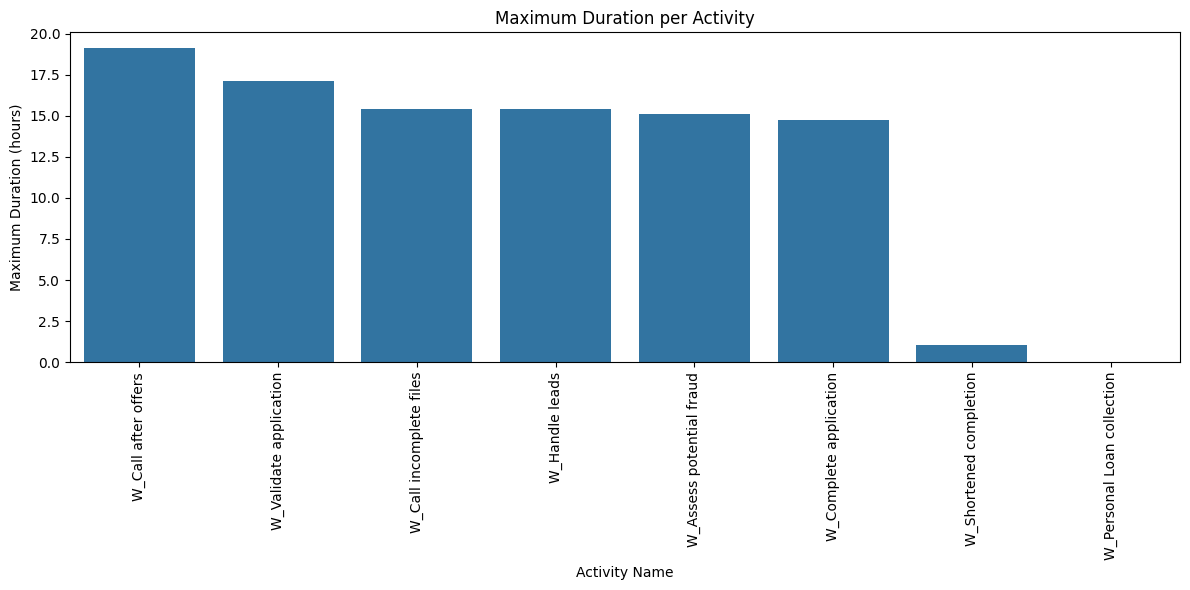

In [9]:
# get maximum durations per activity_name
max_durations = timeline_df.groupby("activity_name")["duration_hours"].max().reset_index()
max_durations.columns = ["activity_name", "max_duration"]
max_durations.sort_values("max_duration", ascending=False, inplace=True)
plt.figure(figsize=(12, 6))
sns.barplot(x="activity_name", y="max_duration", data=max_durations)
plt.xticks(rotation=90)
plt.title("Maximum Duration per Activity")
plt.xlabel("Activity Name")
plt.ylabel("Maximum Duration (hours)")
plt.tight_layout()
plt.show()

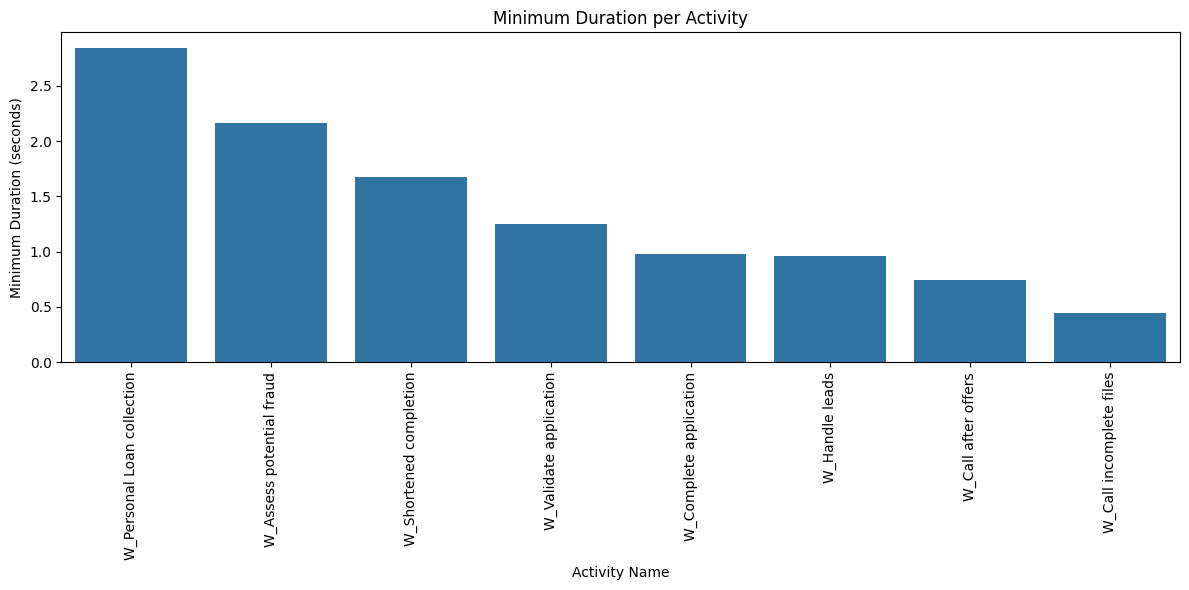

In [10]:
# get maximum durations per activity_name
min_durations = timeline_df.groupby("activity_name")["duration_hours"].min().reset_index()
# calculate min duraiton in seconds:
min_durations["min_duration_seconds"] = min_durations["duration_hours"] * 3600.0
# min_durations.columns = ["activity_name", "min_duration_seconds"]
min_durations.sort_values("min_duration_seconds", ascending=False, inplace=True)
plt.figure(figsize=(12, 6))
sns.barplot(x="activity_name", y="min_duration_seconds", data=min_durations)
plt.xticks(rotation=90)
plt.title("Minimum Duration per Activity")
plt.xlabel("Activity Name")
plt.ylabel("Minimum Duration (seconds)")
plt.tight_layout()
plt.show()

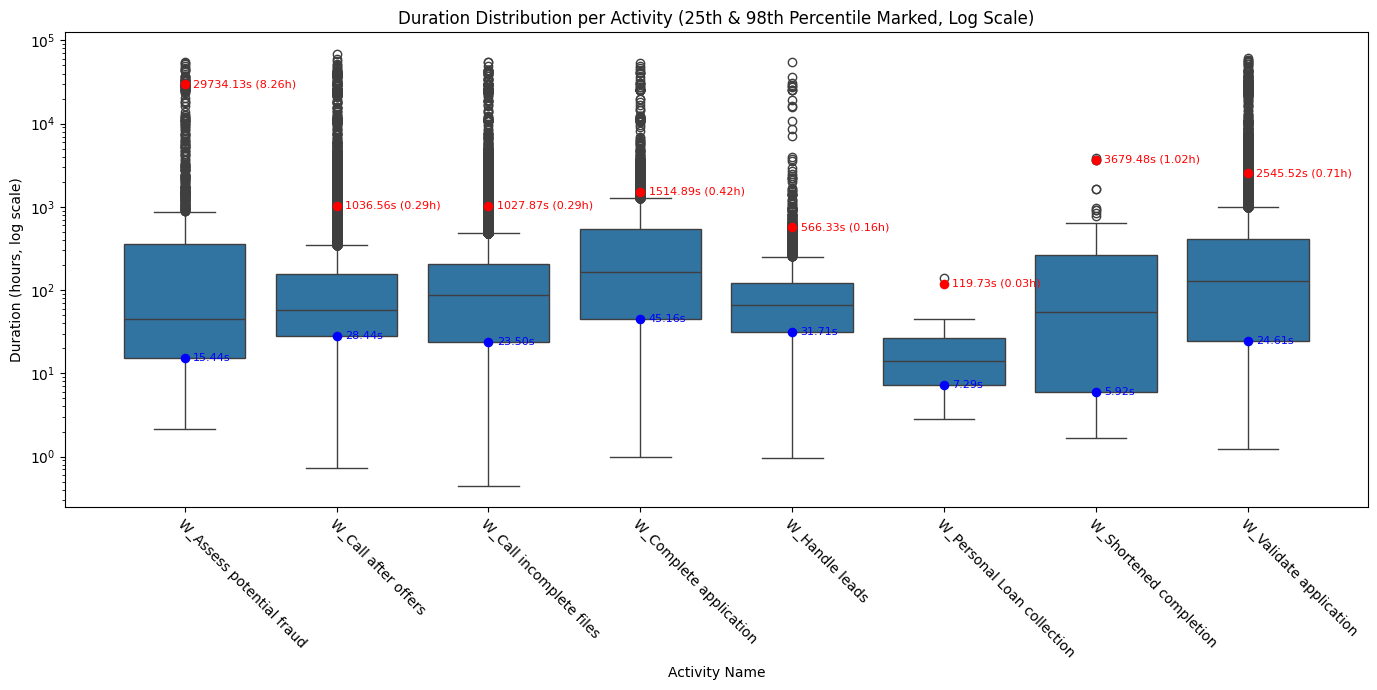

In [11]:
# analyze duration distribution per activity with 95th percentile marker + label (log y-axis)
plot_df = timeline_df[timeline_df["duration_seconds"] > 0].copy()
activity_order = sorted(plot_df["activity_name"].dropna().unique().tolist())
percentile_95 = plot_df.groupby("activity_name")["duration_seconds"].quantile(0.98)
percentile_05 = plot_df.groupby("activity_name")["duration_seconds"].quantile(0.25)

plt.figure(figsize=(14, 7))
ax = sns.boxplot(
    x="activity_name",
    y="duration_seconds",
    data=plot_df,
    order=activity_order,
    showfliers=True
 )

# mark only the 95th percentile per activity and annotate in hours
for i, activity in enumerate(activity_order):
    p95 = percentile_95.get(activity, None)
    p05 = percentile_05.get(activity, None)
    if p95 is None or pd.isna(p95) or p95 <= 0:
        continue
    ax.scatter(i, p95, color="red", s=35, zorder=5)
    ax.scatter(i, p05, color="blue", s=35, zorder=5)
    ax.annotate(
        f"{p95:.2f}s ({p95/3600:.2f}h)",
        xy=(i, p95),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color="red"
    )
    ax.annotate(
        f"{p05:.2f}s",
        xy=(i, p05),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=8,
        color="blue"
    )

ax.set_yscale("log")
plt.xticks(rotation=-45, ha="left", rotation_mode="anchor")
plt.title("Duration Distribution per Activity (25th & 98th Percentile Marked, Log Scale)")
plt.xlabel("Activity Name")
plt.ylabel("Duration (hours, log scale)")
plt.tight_layout()
plt.show()

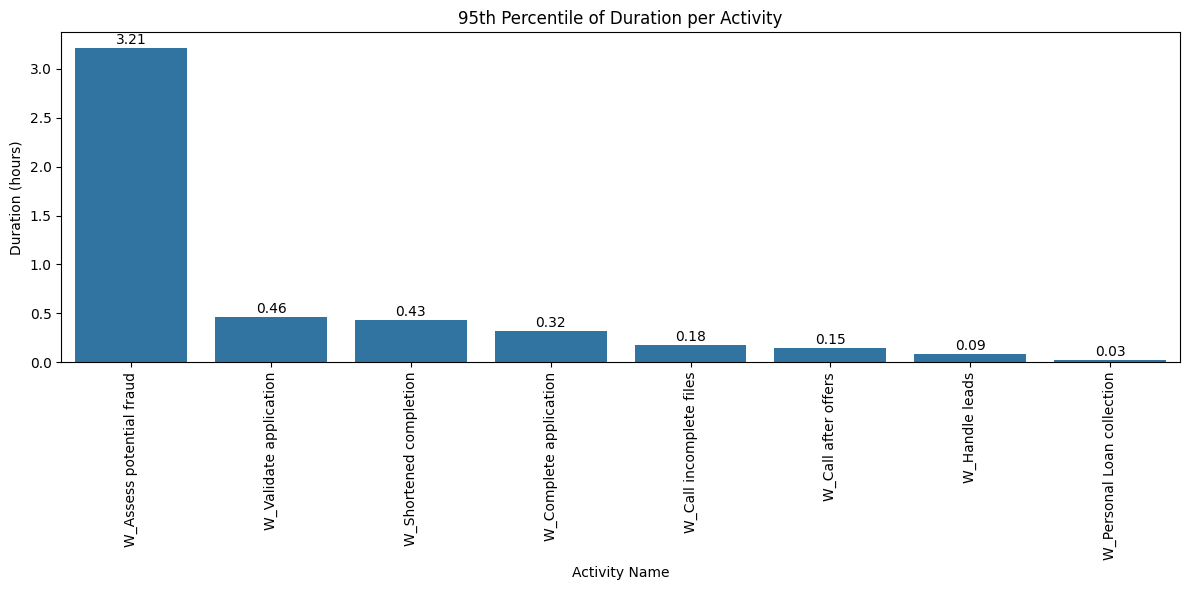

In [12]:
# print the 95th percentile of the durations per activity_name and include the values in the plot
percentiles = timeline_df.groupby("activity_name")["duration_hours"].quantile(0.95).reset_index()
percentiles.columns = ["activity_name", "duration_95th_percentile"]
percentiles.sort_values("duration_95th_percentile", ascending=False, inplace=True)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="activity_name", y="duration_95th_percentile", data=percentiles)
# Add value labels on bars
for i, (index, row) in enumerate(percentiles.iterrows()):
    ax.text(i, row["duration_95th_percentile"] + 0.01, f"{row['duration_95th_percentile']:.2f}", ha='center', va='bottom')
plt.xticks(rotation=90)
plt.title("95th Percentile of Duration per Activity")
plt.xlabel("Activity Name")
plt.ylabel("Duration (hours)")
plt.tight_layout()
plt.show()

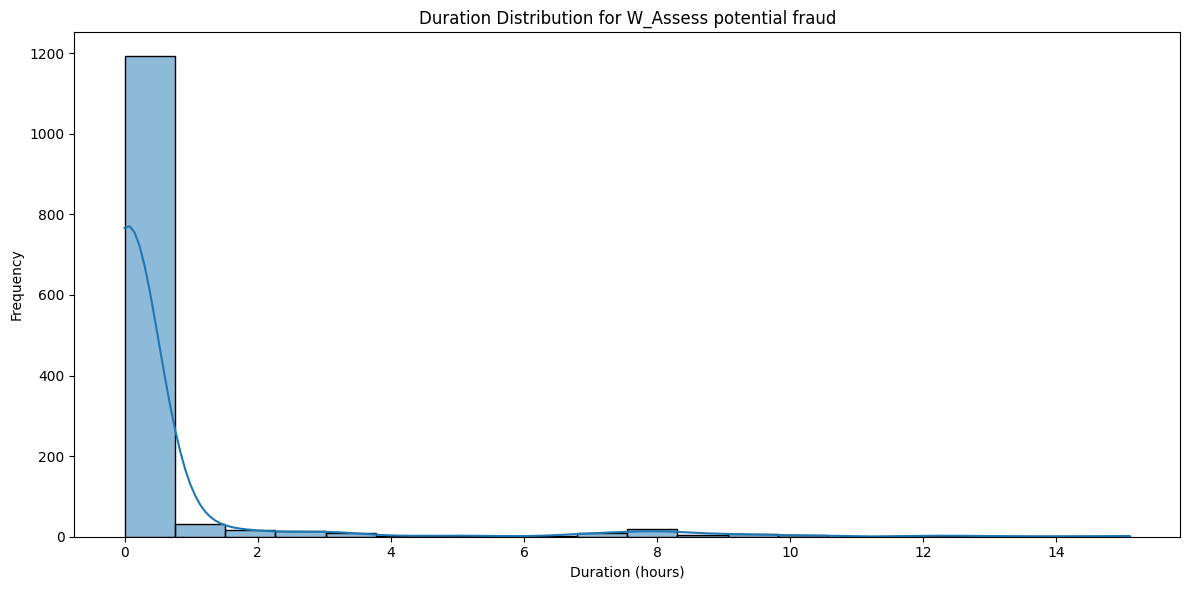

In [13]:
# now analyze only the W_Assess potential fraud activity
fraud_df = timeline_df[timeline_df["activity_name"] == "W_Assess potential fraud"]
plt.figure(figsize=(12, 6))
sns.histplot(fraud_df["duration_hours"], bins=20, kde=True)
plt.title("Duration Distribution for W_Assess potential fraud")
plt.xlabel("Duration (hours)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [14]:
df = timeline_df[(timeline_df["activity_name"] == "W_Assess potential fraud") & (timeline_df["duration_hours"] > 10.0)]

In [15]:
df.sort_values(by="start_timestamp", ascending=True).head(30)

,case_id,activity_name,resource_id,start_timestamp,complete_timestamp,duration_seconds,segment_count,resource_count,active_ratio,LoanGoal,ApplicationType,duration_hours
241626,Application_900460993,W_Assess potential fraud,User_144,2016-03-21 08:00:38.803000+00:00,2016-03-21 23:00:22.614000+00:00,53983.811,7.0,5.0,0.1707,Car,New credit,14.995503
246595,Application_939691189,W_Assess potential fraud,User_144,2016-04-07 11:29:27.094000+00:00,2016-04-07 22:00:21.921000+00:00,37854.827,12.0,5.0,0.0380,Car,New credit,10.515230
144692,Application_2093424318,W_Assess potential fraud,User_144,2016-05-02 13:23:04.732000+00:00,2016-05-03 03:05:07.832000+00:00,49323.100,9.0,3.0,0.1155,Car,New credit,13.700861
410,Application_1003257895,W_Assess potential fraud,User_144,2016-06-15 11:00:23.192000+00:00,2016-06-16 02:06:26.399000+00:00,54363.207,3.0,2.0,0.2985,Unknown,New credit,15.100891
5906,Application_1046585954,W_Assess potential fraud,User_143,2016-07-07 11:59:31.186000+00:00,2016-07-07 22:00:40.495000+00:00,36069.309,4.0,4.0,0.1098,Existing loan takeover,New credit,10.019253
188768,Application_493974108,W_Assess potential fraud,User_144,2016-07-13 09:15:53.963000+00:00,2016-07-13 22:00:30.616000+00:00,45876.653,4.0,2.0,0.4499,Existing loan takeover,New credit,12.743515
77320,Application_158116531,W_Assess potential fraud,User_144,2016-07-22 11:48:13.771000+00:00,2016-07-22 22:00:13.726000+00:00,36719.955,3.0,2.0,0.1540,Home improvement,New credit,10.199988
212192,Application_671678776,W_Assess potential fraud,User_55,2016-10-14 09:51:42.769000+00:00,2016-10-14 22:00:02.248000+00:00,43699.479,2.0,1.0,0.3553,Car,New credit,12.138744
106062,Application_1796529138,W_Assess potential fraud,User_138,2016-10-20 09:08:40.035000+00:00,2016-10-20 22:00:01.997000+00:00,46281.962,12.0,7.0,0.0454,Home improvement,New credit,12.856101
246413,Application_938318297,W_Assess potential fraud,User_138,2016-11-03 10:49:18.263000+00:00,2016-11-03 23:00:01.683000+00:00,43843.420,13.0,8.0,0.0821,Existing loan takeover,New credit,12.178728


In [16]:
# show top resources for activity W_Assess potential fraud
top_resources = timeline_df[timeline_df["activity_name"] == "W_Assess potential fraud"]["resource_id"].value_counts().head(10)
print(top_resources)

resource_id
User_144    270
User_138    251
User_143    154
User_100     83
User_36      68
User_83      66
User_68      48
User_55      35
User_29      31
User_54      27
Name: count, dtype: int64
